In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,
                             silhouette_score,calinski_harabasz_score,davies_bouldin_score,roc_curve)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False


In [ ]:
df = pd.read_csv('/content/Fashion_Retail_Sales.csv')

In [ ]:
print("Initial shape:", df.shape)

Initial shape: (3400, 6)


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB
None


In [ ]:
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


In [ ]:
df.columns = [c.strip() for c in df.columns]

df = df.rename(columns={
    "Customer Reference ID": "CustomerID",
    "Item Purchased": "ItemPurchased",
    "Purchase Amount (USD)": "PurchaseAmount",
    "Date Purchase": "PurchaseDate",
    "Review Rating": "ReviewRating",
    "Payment Method": "PaymentMethod"
})

In [ ]:
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
df["PurchaseAmount"] = pd.to_numeric(df["PurchaseAmount"], errors="coerce")
df["ReviewRating"] = pd.to_numeric(df["ReviewRating"], errors="coerce")

df["ItemPurchased"] = df["ItemPurchased"].astype(str).str.strip()
df["PaymentMethod"] = df["PaymentMethod"].astype(str).str.strip()
df["PurchaseDate"] = pd.to_datetime(df["PurchaseDate"], errors="coerce", dayfirst=True)


In [ ]:
before = len(df)
df = df.drop_duplicates().copy()
print("\nDuplicates removed:", before - len(df))


Duplicates removed: 0


In [ ]:
df = df.dropna(subset=["CustomerID", "ItemPurchased", "PurchaseAmount", "PurchaseDate", "PaymentMethod"]).copy()
df = df[df["PurchaseAmount"] > 0].copy()

In [ ]:
df["ReviewRating"] = df.groupby("CustomerID")["ReviewRating"].transform(lambda x: x.fillna(x.mean()))
df["ReviewRating"] = df["ReviewRating"].fillna(df["ReviewRating"].median())

In [ ]:
df["CustomerID"] = df["CustomerID"].astype(int)


In [ ]:
print("\nCleaned shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isna().sum())


Cleaned shape: (2750, 6)

Missing values after cleaning:
CustomerID        0
ItemPurchased     0
PurchaseAmount    0
PurchaseDate      0
ReviewRating      0
PaymentMethod     0
dtype: int64


In [ ]:
df["Year"] = df["PurchaseDate"].dt.year
df["Month"] = df["PurchaseDate"].dt.month
df["Day"] = df["PurchaseDate"].dt.day
df["DayOfWeek"] = df["PurchaseDate"].dt.day_name()
df["Quarter"] = df["PurchaseDate"].dt.quarter
df["IsWeekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"]).astype(int)

print("\nDate range:")
print("Min date:", df["PurchaseDate"].min())
print("Max date:", df["PurchaseDate"].max())


Date range:
Min date: 2022-10-02 00:00:00
Max date: 2023-10-01 00:00:00


In [ ]:
def safe_mode(series):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan


In [ ]:
snapshot_date = df["PurchaseDate"].max() + pd.Timedelta(days=1)

rfm_df = df.groupby("CustomerID").agg(
    recency_days=("PurchaseDate", lambda x: (snapshot_date - x.max()).days),
    frequency=("PurchaseDate", "count"),
    monetary=("PurchaseAmount", "sum"),
    avg_purchase=("PurchaseAmount", "mean"),
    avg_rating=("ReviewRating", "mean"),
    item_diversity=("ItemPurchased", "nunique"),
    preferred_payment=("PaymentMethod", safe_mode)
).reset_index()

rfm_df["R_score"] = pd.qcut(rfm_df["recency_days"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df["F_score"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["M_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["RFM_Total"] = rfm_df[["R_score", "F_score", "M_score"]].sum(axis=1)

def assign_rfm_segment(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Champions"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] == 4 and row["F_score"] <= 2:
        return "Recent Customers"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    elif row["R_score"] == 1 and row["F_score"] <= 2:
        return "Lost Customers"
    else:
        return "Potential Loyalists"

rfm_df["RFM_Segment"] = rfm_df.apply(assign_rfm_segment, axis=1)

print("\nRFM Segment Counts:")
print(rfm_df["RFM_Segment"].value_counts())
rfm_df.to_csv("fashion_rfm_segmentation.csv", index=False)


RFM Segment Counts:
RFM_Segment
Potential Loyalists    39
Champions              36
At Risk                35
Lost Customers         30
Recent Customers       14
Loyal Customers        12
Name: count, dtype: int64



Cluster evaluation:
   k  silhouette_score  calinski_harabasz_score  davies_bouldin_score
0  2          0.354613                63.959016              1.336921
1  3          0.259482                66.044004              1.229374
2  4          0.245169                58.388297              1.232482
3  5          0.242086                55.280299              1.314336
4  6          0.226828                53.032312              1.271368

Best number of clusters: 2

Cluster summary:
         customers  avg_recency  avg_frequency  avg_monetary  avg_rating
Cluster                                                                 
0               41     21.95122      18.365854   5336.487805    3.155344
1              125     25.42400      15.976000   1697.248000    2.937476


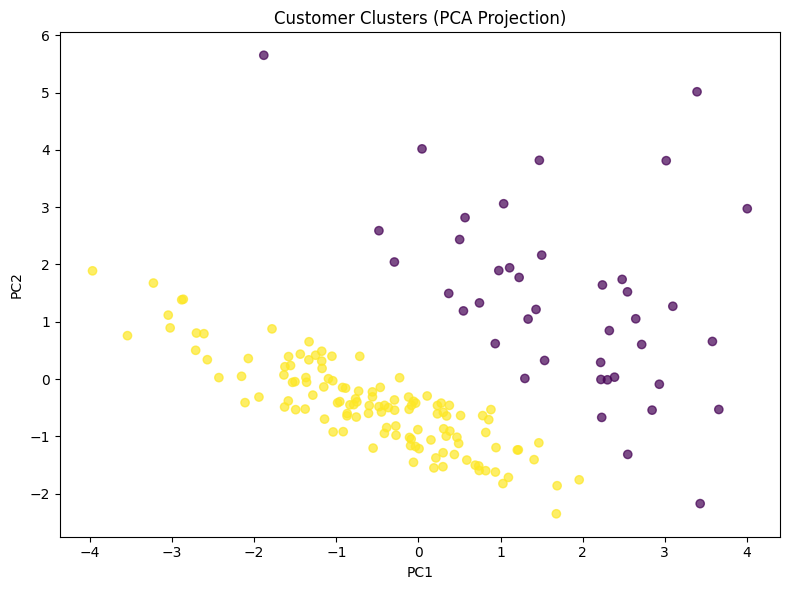

In [ ]:
RANDOM_STATE = 42

cluster_features = rfm_df[
    ["recency_days", "frequency", "monetary", "avg_purchase", "avg_rating", "item_diversity"]
].copy()

cluster_features = cluster_features.fillna(cluster_features.median(numeric_only=True))
cluster_scaled = StandardScaler().fit_transform(cluster_features)

cluster_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(cluster_scaled)
    cluster_scores.append({
        "k": k,
        "silhouette_score": silhouette_score(cluster_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(cluster_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(cluster_scaled, labels)
    })

cluster_scores_df = pd.DataFrame(cluster_scores)
print("\nCluster evaluation:")
print(cluster_scores_df)

best_k = int(cluster_scores_df.sort_values(by="silhouette_score", ascending=False).iloc[0]["k"])
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
rfm_df["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_summary = rfm_df.groupby("Cluster").agg(
    customers=("CustomerID", "count"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_rating=("avg_rating", "mean")
).sort_values(by="avg_monetary", ascending=False)

print("\nBest number of clusters:", best_k)
print("\nCluster summary:")
print(cluster_summary)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=rfm_df["Cluster"], alpha=0.7)
plt.title("Customer Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [ ]:
df = df.sort_values(["CustomerID", "PurchaseDate"]).copy()
df["prev_purchase"] = df.groupby("CustomerID")["PurchaseDate"].shift(1)
df["gap_days"] = (df["PurchaseDate"] - df["prev_purchase"]).dt.days

customer_df = df.groupby("CustomerID").agg(
    purchase_count=("PurchaseDate", "count"),
    total_spend=("PurchaseAmount", "sum"),
    avg_spend=("PurchaseAmount", "mean"),
    std_spend=("PurchaseAmount", "std"),
    min_spend=("PurchaseAmount", "min"),
    max_spend=("PurchaseAmount", "max"),
    median_spend=("PurchaseAmount", "median"),
    avg_rating=("ReviewRating", "mean"),
    std_rating=("ReviewRating", "std"),
    min_rating=("ReviewRating", "min"),
    max_rating=("ReviewRating", "max"),
    item_diversity=("ItemPurchased", "nunique"),
    preferred_item=("ItemPurchased", safe_mode),
    preferred_payment=("PaymentMethod", safe_mode),
    first_purchase=("PurchaseDate", "min"),
    last_purchase=("PurchaseDate", "max"),
    most_common_month=("Month", safe_mode),
    weekend_ratio=("IsWeekend", "mean"),
    avg_gap_days=("gap_days", "mean"),
    std_gap_days=("gap_days", "std"),
    max_gap_days=("gap_days", "max")
).reset_index()

customer_df["customer_age_days"] = (customer_df["last_purchase"] - customer_df["first_purchase"]).dt.days.clip(lower=0)
customer_df["days_since_last_purchase"] = (snapshot_date - customer_df["last_purchase"]).dt.days.clip(lower=0)
customer_df["purchase_frequency_per_30d"] = customer_df["purchase_count"] / ((customer_df["customer_age_days"] / 30.0) + 1.0)
customer_df["spend_per_unique_item"] = customer_df["total_spend"] / (customer_df["item_diversity"] + 1e-6)

for col in ["std_spend", "std_rating", "avg_gap_days", "std_gap_days", "max_gap_days"]:
    customer_df[col] = customer_df[col].fillna(0)

customer_df = customer_df.merge(
    rfm_df[["CustomerID", "recency_days", "frequency", "RFM_Total", "RFM_Segment", "Cluster"]],
    on="CustomerID",
    how="left"
)

In [ ]:
high_value_threshold = customer_df["total_spend"].quantile(0.60)
customer_df["high_value_customer"] = (customer_df["total_spend"] >= high_value_threshold).astype(int)

print("\nHigh-value customer distribution:")
print(customer_df["high_value_customer"].value_counts())
print(customer_df["high_value_customer"].value_counts(normalize=True))



High-value customer distribution:
high_value_customer
0    99
1    67
Name: count, dtype: int64
high_value_customer
0    0.596386
1    0.403614
Name: proportion, dtype: float64


In [ ]:
feature_cols = [
    "purchase_count", "avg_spend", "std_spend", "min_spend", "max_spend", "median_spend",
    "avg_rating", "std_rating", "min_rating", "max_rating",
    "item_diversity", "preferred_payment", "preferred_item",
    "most_common_month", "weekend_ratio",
    "avg_gap_days", "std_gap_days", "max_gap_days",
    "customer_age_days", "days_since_last_purchase",
    "purchase_frequency_per_30d", "spend_per_unique_item",
    "recency_days", "frequency", "RFM_Total", "RFM_Segment", "Cluster"
]

X = customer_df[feature_cols].copy()
y = customer_df["high_value_customer"].copy()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [c for c in X.columns if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (132, 27)
Test shape: (34, 27)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_model = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

estimators = [
    ("rf", rf_model),
    ("et", et_model),
    ("lr", log_model)
]

if XGB_AVAILABLE:
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.90,
        colsample_bytree=0.90,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight
    )
    estimators.append(("xgb", xgb_model))

voting_model = VotingClassifier(
    estimators=estimators,
    voting="soft"
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", voting_model)
])


In [ ]:
param_grid = {
    "model__weights": [
        [1, 1, 1] if not XGB_AVAILABLE else [1, 1, 1, 1],
        [2, 1, 1] if not XGB_AVAILABLE else [2, 1, 1, 1],
        [1, 2, 1] if not XGB_AVAILABLE else [1, 2, 1, 1],
        [1, 1, 2] if not XGB_AVAILABLE else [1, 1, 2, 1],
        [2, 2, 1] if not XGB_AVAILABLE else [2, 2, 1, 1],
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest parameters for accuracy:")
print(grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

final_model = grid.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters for accuracy:
{'model__weights': [2, 1, 1, 1]}
Best CV Accuracy: 0.9547


In [ ]:
train_prob = final_model.predict_proba(X_train)[:, 1]
test_prob = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for thr in thresholds:
    train_pred_thr = (train_prob >= thr).astype(int)
    threshold_results.append({
        "threshold": thr,
        "train_accuracy": accuracy_score(y_train, train_pred_thr),
        "train_precision": precision_score(y_train, train_pred_thr, zero_division=0),
        "train_recall": recall_score(y_train, train_pred_thr, zero_division=0),
        "train_f1": f1_score(y_train, train_pred_thr, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold = threshold_df.sort_values(by="train_accuracy", ascending=False).iloc[0]["threshold"]

print("\nBest threshold selected from training set:", best_threshold)
print("\nTop threshold candidates:")
print(threshold_df.sort_values(by="train_accuracy", ascending=False).head(10))


Best threshold selected from training set: 0.5499999999999998

Top threshold candidates:
    threshold  train_accuracy  train_precision  train_recall  train_f1
45       0.55             1.0              1.0           1.0       1.0
33       0.43             1.0              1.0           1.0       1.0
34       0.44             1.0              1.0           1.0       1.0
35       0.45             1.0              1.0           1.0       1.0
36       0.46             1.0              1.0           1.0       1.0
37       0.47             1.0              1.0           1.0       1.0
38       0.48             1.0              1.0           1.0       1.0
39       0.49             1.0              1.0           1.0       1.0
40       0.50             1.0              1.0           1.0       1.0
41       0.51             1.0              1.0           1.0       1.0



Final holdout metrics:
Accuracy : 0.9118
Precision: 0.9231
Recall   : 0.8571
F1 Score : 0.8889
ROC_AUC  : 0.9821

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.92      0.86      0.89        14

    accuracy                           0.91        34
   macro avg       0.91      0.90      0.91        34
weighted avg       0.91      0.91      0.91        34



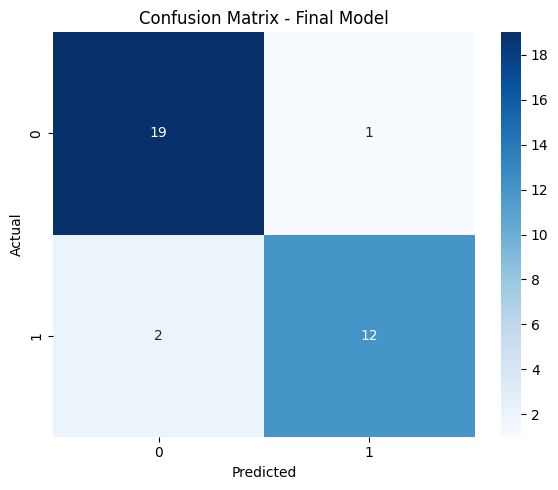

In [ ]:
final_test_pred = (test_prob >= best_threshold).astype(int)

print("\nFinal holdout metrics:")
print("Accuracy :", round(accuracy_score(y_test, final_test_pred), 4))
print("Precision:", round(precision_score(y_test, final_test_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, final_test_pred), 4))
print("F1 Score :", round(f1_score(y_test, final_test_pred), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, test_prob), 4))

print("\nClassification report:")
print(classification_report(y_test, final_test_pred))

cm = confusion_matrix(y_test, final_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

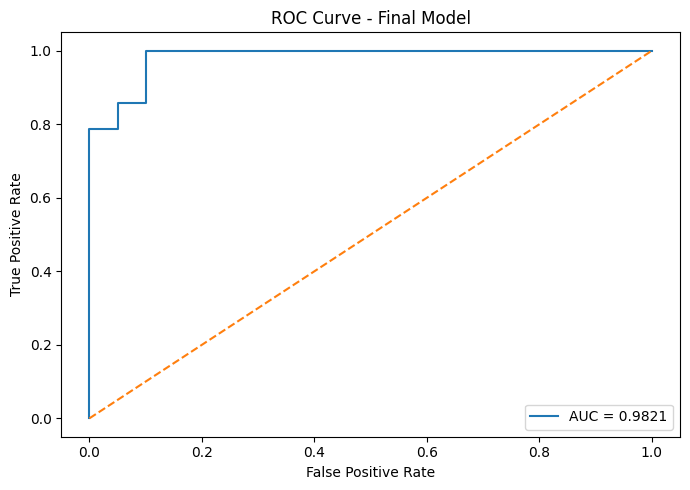

In [ ]:

fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
threshold_df.to_csv("fashion_threshold_tuning_results.csv", index=False)
cluster_summary.to_csv("fashion_cluster_summary.csv")

prediction_output = customer_df.loc[X_test.index, ["CustomerID"]].copy()
prediction_output["actual_high_value"] = y_test.values
prediction_output["predicted_high_value"] = final_test_pred
prediction_output["high_value_probability"] = test_prob
prediction_output = prediction_output.sort_values(by="high_value_probability", ascending=False)
prediction_output.to_csv("fashion_high_value_predictions.csv", index=False)

print("\nFiles exported successfully:")
print("- fashion_threshold_tuning_results.csv")
print("- fashion_cluster_summary.csv")
print("- fashion_high_value_predictions.csv")


Files exported successfully:
- fashion_threshold_tuning_results.csv
- fashion_cluster_summary.csv
- fashion_high_value_predictions.csv
